# Recovering Asteroid Rotation Periods from Sparse Light Curves
### Unit 20 — Initial Report & Exploratory Data Analysis

**Research question.** Can a supervised machine-learning model accurately recover an
asteroid's rotation period from sparse, irregularly-sampled light-curve data —
telling the true period apart from the aliases that simpler methods produce —
reliably enough to be useful on large survey datasets where dedicated follow-up
isn't possible?

**Why it matters.** An asteroid's spin rate constrains its internal structure
(a solid body vs. a gravitationally-bound "rubble pile"), which has both
scientific and planetary-defense value. Surveys like the Rubin Observatory are
about to increase the number of known asteroids several-fold, but each object is
observed only sparsely — too sparse for the classical dense-photometry methods
used to measure rotation. A model that recovers reliable periods from sparse data
turns already-collected observations into usable measurements at no extra cost.

**This notebook (Unit 20)** builds the data foundation and baseline: it loads and
characterizes the data, then sets up the controlled-sparsity experiment and a
non-ML baseline. Additional models and refinement follow in Unit 24.

## 1. Data sources & structure

| Source | Role | Structure |
|---|---|---|
| **LCDB** (Asteroid Lightcurve Database) | **Labels** — published rotation periods + quality codes | Fixed-width summary table, one row per asteroid |
| **ALCDEF** (Asteroid Lightcurve Data Exchange Format) | **Dense light curves** — the raw material we down-sample | One file per asteroid; per-session `(JD, magnitude, uncertainty)` blocks |
| ZTF / Gaia DR3 *(planned, Unit 24)* | Real-world **sparse test sets** | Wide-survey sparse photometry |

The labels come from LCDB filtered to quality code **U ≥ 2** (reliable period
determinations). The light curves come from ALCDEF. An asteroid enters the study
only if it has *both* a reliable period and at least one ALCDEF curve. Loading and
parsing for both sources lives in [`src/data_loading.py`](src/data_loading.py).

## 2. Setup

In [1]:
import sys
from pathlib import Path

# The notebook runs from the repo root; make src/ importable.
sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from data_loading import (
    load_lcdb_summary,
    reliable_labels,
    has_alcdef,
    load_alcdef_blocks,
    object_photometry,
    build_coverage_table,
)

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)

# A consistent, readable plotting style for the whole notebook.
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
BLUE, GREEN, RED, PURPLE, ORANGE = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#DD8452"

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

## 3. The labels (LCDB)

We load the full LCDB summary, then filter to reliable period determinations
(**U ≥ 2**, with a numeric period). The U code is an ordered half-step quality
scale (3 is best; see `parse_u_code`); `reliable_labels` encodes it numerically
so it can be filtered and plotted.

In [2]:
lcdb = load_lcdb_summary()
labels = reliable_labels(lcdb, min_u=2.0)

print(f"LCDB summary rows (all):           {len(lcdb):>7,}")
print(f"Reliable labels (U>=2, has period):{len(labels):>7,}")

labels[["number", "name", "class", "period_h", "amp_max", "U", "diam_km", "H"]].head(8)

LCDB summary rows (all):            36,259
Reliable labels (U>=2, has period): 29,729


,number,name,class,period_h,amp_max,U,diam_km,H
0,1,Ceres,C,9.07417,0.06,3,939.40,3.53
1,2,Pallas,B,7.81320,0.16,3,512.22,4.13
2,3,Juno,S,7.21000,0.22,3,257.88,5.28
3,4,Vesta,V,5.34200,0.19,3,525.00,3.20
4,5,Astraea,S,16.80600,0.27,3,115.00,6.85
5,6,Hebe,S,7.27450,0.21,3,183.41,5.60
6,7,Iris,S,7.13900,0.37,3,198.97,5.60
7,8,Flora,S,12.86500,0.11,3,138.79,6.56


### 3.1 Period and amplitude distributions

Rotation period spans several orders of magnitude, so it is shown on a log scale.
The dashed line marks the classical **~2.2 h "spin barrier"** — below it, a
strengthless rubble pile would fly apart, so faster rotators are (mostly) small
monolithic bodies. Amplitude (peak-to-peak brightness variation) is a proxy for
shape elongation and, as we will see, for how easy a period is to recover.

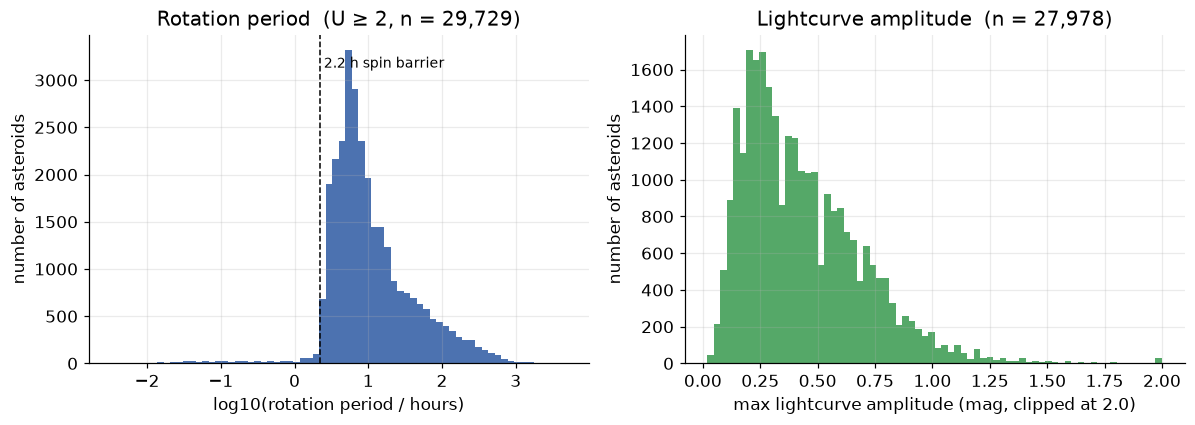

Period (hours) summary:
min       0.003
25%       4.770
50%       7.867
75%      19.862
max    4812.000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

p = labels["period_h"].dropna()
p = p[p > 0]
axes[0].hist(np.log10(p), bins=70, color=BLUE)
axes[0].axvline(np.log10(2.2), ls="--", color="k", lw=1)
axes[0].text(np.log10(2.2), axes[0].get_ylim()[1]*0.9, " 2.2 h spin barrier", fontsize=9)
axes[0].set_xlabel("log10(rotation period / hours)")
axes[0].set_ylabel("number of asteroids")
axes[0].set_title(f"Rotation period  (U ≥ 2, n = {len(p):,})")

a = labels["amp_max"].dropna()
a = a[a > 0]
axes[1].hist(a.clip(upper=2.0), bins=70, color=GREEN)
axes[1].set_xlabel("max lightcurve amplitude (mag, clipped at 2.0)")
axes[1].set_ylabel("number of asteroids")
axes[1].set_title(f"Lightcurve amplitude  (n = {len(a):,})")

fig.tight_layout()
fig.savefig(FIGDIR / "labels_period_amplitude.png", bbox_inches="tight")
plt.show()

print("Period (hours) summary:")
print(p.describe()[["min", "25%", "50%", "75%", "max"]].round(3).to_string())

### 3.2 Quality codes and taxonomic classes

The U-code distribution shows how much data we discard by requiring U ≥ 2, and the
taxonomic-class mix tells us which asteroid types dominate the labels — relevant to
the proposal's question of *which kinds of asteroids are easier or harder* to handle.

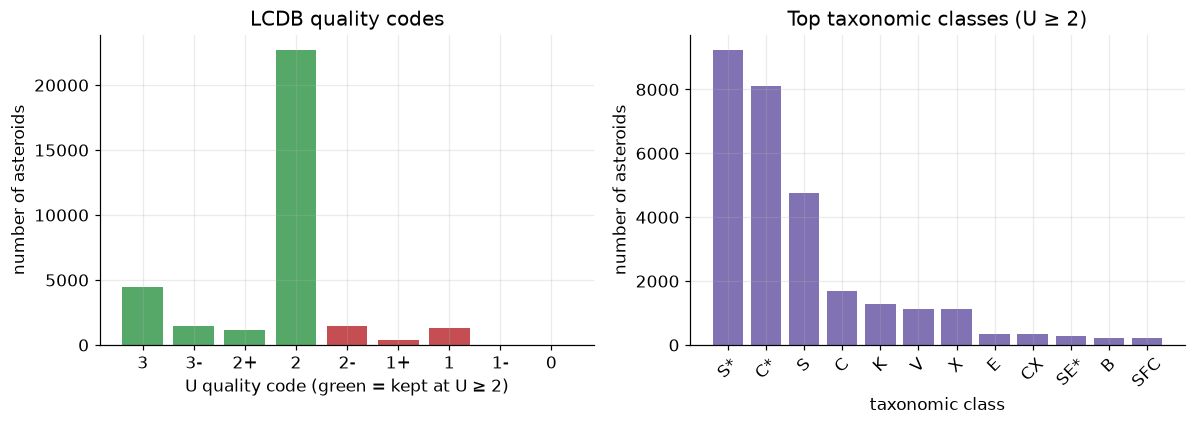

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

u_order = ["3", "3-", "2+", "2", "2-", "1+", "1", "1-", "0"]
u_counts = lcdb["U"].value_counts().reindex(u_order).fillna(0)
colors = [GREEN if u in {"3", "3-", "2+", "2"} else RED for u in u_order]
axes[0].bar(u_order, u_counts.values, color=colors)
axes[0].set_xlabel("U quality code (green = kept at U ≥ 2)")
axes[0].set_ylabel("number of asteroids")
axes[0].set_title("LCDB quality codes")

top_classes = (labels["class"].replace("", np.nan).dropna()
               .value_counts().head(12))
axes[1].bar(top_classes.index, top_classes.values, color=PURPLE)
axes[1].set_xlabel("taxonomic class")
axes[1].set_ylabel("number of asteroids")
axes[1].set_title("Top taxonomic classes (U ≥ 2)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(FIGDIR / "labels_quality_class.png", bbox_inches="tight")
plt.show()

## 4. The light curves (ALCDEF)

Each ALCDEF file is a set of observing **sessions** (blocks), each a run of
`(JD, magnitude, uncertainty)` points from one night. Crucially, magnitudes are
**not** reduced to a common zero-point — each session has its own offset — so
sessions must be treated separately rather than concatenated blindly.

To characterize coverage across the whole dataset we precompute a per-object
**coverage table** (sessions, points, distinct nights, time span, longest single
session) with one pass over the archive. It is cached under `data/interim/`; the
cell rebuilds it from the raw zip if the cache is absent.

In [5]:
COV_PATH = Path("data/interim/coverage_summary.parquet")

if COV_PATH.exists():
    cov = pd.read_parquet(COV_PATH)
else:
    nums = sorted(int(n) for n in labels["number"].dropna() if has_alcdef(int(n)))
    cov = build_coverage_table(nums)
    COV_PATH.parent.mkdir(parents=True, exist_ok=True)
    cov.to_parquet(COV_PATH, index=False)

print(f"objects with a coverage summary: {len(cov):,}")
cov[["number", "n_sessions", "n_points", "n_nights",
     "jd_span_days", "max_session_points", "n_bands"]].describe().round(2)

objects with a coverage summary: 20,501


,number,n_sessions,n_points,n_nights,jd_span_days,max_session_points,n_bands
count,20501.00,20501.00,20501.00,20501.00,20501.00,20501.00,20501.00
mean,81340.62,17.43,499.08,17.41,431.74,52.03,1.17
std,97004.37,11.01,815.77,10.81,1149.23,76.10,0.46
min,1.00,1.00,2.00,1.00,0.02,2.00,1.00
25%,12919.00,10.00,63.00,10.00,13.56,11.00,1.00
50%,46449.00,16.00,304.00,16.00,25.54,46.00,1.00
75%,112740.00,24.00,724.00,24.00,91.90,47.00,1.00
max,612050.00,189.00,23583.00,184.00,11953.88,1417.00,6.00


### 4.1 How much data does a typical object actually have?

These distributions are the single most important input to the down-sampling
design: they tell us how dense the "dense" ALCDEF curves really are before we
start throwing observations away.

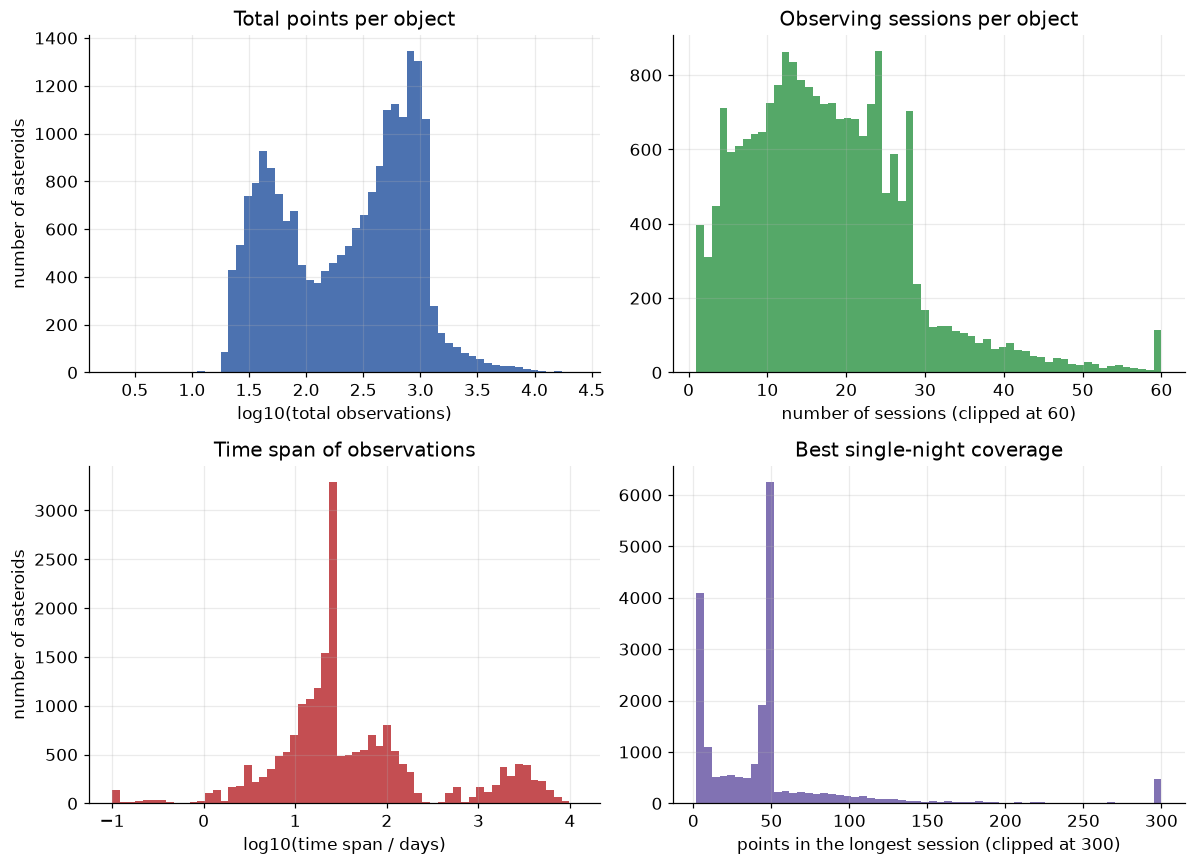

Total points per object — 25th/50th/75th pct: 63 / 304 / 724
Objects with < 50 total observations: 19.5%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(np.log10(cov["n_points"].clip(lower=1)), bins=60, color=BLUE)
axes[0, 0].set_xlabel("log10(total observations)")
axes[0, 0].set_ylabel("number of asteroids")
axes[0, 0].set_title("Total points per object")

axes[0, 1].hist(cov["n_sessions"].clip(upper=60), bins=60, color=GREEN)
axes[0, 1].set_xlabel("number of sessions (clipped at 60)")
axes[0, 1].set_title("Observing sessions per object")

axes[1, 0].hist(np.log10(cov["jd_span_days"].clip(lower=0.1)), bins=60, color=RED)
axes[1, 0].set_xlabel("log10(time span / days)")
axes[1, 0].set_ylabel("number of asteroids")
axes[1, 0].set_title("Time span of observations")

axes[1, 1].hist(cov["max_session_points"].clip(upper=300), bins=60, color=PURPLE)
axes[1, 1].set_xlabel("points in the longest session (clipped at 300)")
axes[1, 1].set_title("Best single-night coverage")

fig.tight_layout()
fig.savefig(FIGDIR / "coverage_distributions.png", bbox_inches="tight")
plt.show()

q = cov["n_points"].quantile([0.25, 0.5, 0.75]).astype(int)
print(f"Total points per object — 25th/50th/75th pct: {q.iloc[0]} / {q.iloc[1]} / {q.iloc[2]}")
sparse = (cov["n_points"] < 50).mean() * 100
print(f"Objects with < 50 total observations: {sparse:.1f}%")

## 5. The modeling dataset (labels ⋈ curves)

Joining reliable labels to coverage on the asteroid number gives the set of
objects usable for supervised learning: each has a trustworthy period *and* a
light curve to (down-)sample.

In [7]:
data = labels.merge(cov, on="number", how="inner")
print(f"Modeling dataset (labeled AND has curve): {len(data):,} asteroids")

data[["number", "name", "class", "period_h", "amp_max", "U",
      "n_sessions", "n_points", "n_nights", "max_session_points"]].head(10)

Modeling dataset (labeled AND has curve): 20,501 asteroids


,number,name,class,period_h,amp_max,U,n_sessions,n_points,n_nights,max_session_points
0,1,Ceres,C,9.07417,0.06,3,5,1210,5,465
1,3,Juno,S,7.21000,0.22,3,18,1523,18,260
2,4,Vesta,V,5.34200,0.19,3,29,3382,39,357
3,6,Hebe,S,7.27450,0.21,3,9,388,9,47
4,7,Iris,S,7.13900,0.37,3,29,1999,29,355
5,8,Flora,S,12.86500,0.11,3,8,2164,14,318
6,9,Metis,S,5.07900,0.32,3,4,2957,4,892
7,10,Hygiea,C,13.82800,0.27,3,18,12153,16,1325
8,11,Parthenope,S,13.72040,0.12,3,85,21725,93,463
9,12,Victoria,L,8.65990,0.42,3,11,3017,15,369


### 5.1 Not every labeled curve is "dense"

The proposal's premise is to take *dense* curves and down-sample them. But the
coverage EDA shows a large fraction of objects are already sparse. The table below
counts how many objects clear increasingly strict density thresholds — this
defines the pool of genuinely dense curves available as down-sampling sources.

In [8]:
thresholds = [
    ("any curve", data["n_points"] >= 1),
    ("≥ 50 total points", data["n_points"] >= 50),
    ("≥ 100 total points", data["n_points"] >= 100),
    ("≥ 30 points in one session", data["max_session_points"] >= 30),
    ("dense: ≥100 pts AND a ≥30-pt session", (data["n_points"] >= 100) & (data["max_session_points"] >= 30)),
]
summary = pd.DataFrame(
    [(name, int(mask.sum()), f"{mask.mean()*100:.1f}%") for name, mask in thresholds],
    columns=["density threshold", "n asteroids", "share of dataset"],
)
summary

,density threshold,n asteroids,share of dataset
0,any curve,20501,100.0%
1,≥ 50 total points,16507,80.5%
2,≥ 100 total points,13620,66.4%
3,≥ 30 points in one session,13407,65.4%
4,dense: ≥100 pts AND a ≥30-pt session,12785,62.4%


## 6. What a light curve looks like

To make the problem concrete, we plot one well-sampled asteroid: its raw
multi-session photometry (each session in its own color, showing the per-session
zero-point offsets) and its **phase-folded** curve at the known LCDB period. When
folded at the true period, the points collapse onto the characteristic
double-peaked rotation curve — the signal the model must learn to recover from far
fewer points.

Example: (9) Metis   P = 5.079 h,  U = 3,  amp_max = 0.32 mag,  span = 7.1 d


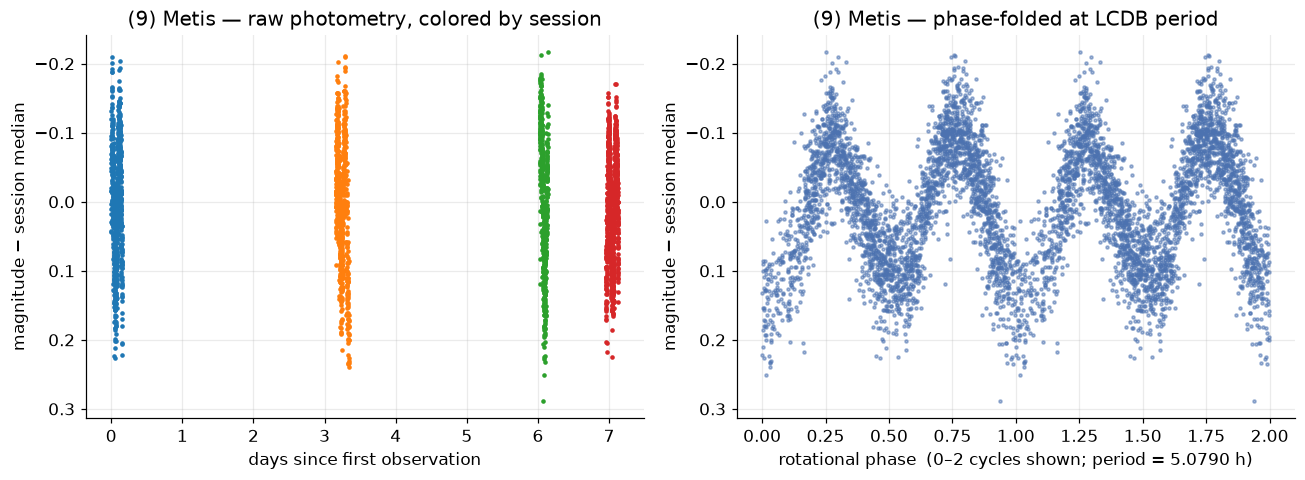

In [9]:
# Pick a densely-sampled fast rotator observed within a *single apparition*
# (short total time span) so the fold stays coherent: folding data taken decades
# apart at a synodic period smears across tens of thousands of cycles.
sel = data[(data["period_h"].between(2.5, 9))
           & (data["amp_max"] >= 0.3)
           & (data["max_session_points"] >= 150)
           & (data["jd_span_days"] <= 30)
           & (data["n_sessions"] >= 3)].sort_values("n_points", ascending=False)
if sel.empty:  # relax if the strict filter finds nothing
    sel = data[(data["period_h"].between(2.5, 9))
               & (data["amp_max"] >= 0.3)
               & (data["jd_span_days"] <= 60)].sort_values("n_points", ascending=False)
row = sel.iloc[0]
num, name, P = int(row["number"]), row["name"], float(row["period_h"])
print(f"Example: ({num}) {name}   P = {P} h,  U = {row['U']},  amp_max = {row['amp_max']} mag,"
      f"  span = {row['jd_span_days']:.1f} d")

phot = object_photometry(num).copy()
# Align each session's zero-point by subtracting its median magnitude.
phot["mag_adj"] = phot["mag"] - phot.groupby("block_id")["mag"].transform("median")
# Robust outlier rejection (median absolute deviation) to drop bad points.
med = phot["mag_adj"].median()
mad = 1.4826 * (phot["mag_adj"] - med).abs().median()
phot = phot[(phot["mag_adj"] - med).abs() < 5 * mad]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for bid, g in phot.groupby("block_id"):
    axes[0].plot(g["jd"] - phot["jd"].min(), g["mag_adj"], ".", ms=4)
axes[0].invert_yaxis()
axes[0].set_xlabel("days since first observation")
axes[0].set_ylabel("magnitude − session median")
axes[0].set_title(f"({num}) {name} — raw photometry, colored by session")

phase = ((phot["jd"] * 24.0) % P) / P
axes[1].plot(phase, phot["mag_adj"], ".", ms=4, color=BLUE, alpha=0.5)
axes[1].plot(phase + 1, phot["mag_adj"], ".", ms=4, color=BLUE, alpha=0.5)  # repeat for continuity
axes[1].invert_yaxis()
axes[1].set_xlabel("rotational phase  (0–2 cycles shown; period = %.4f h)" % P)
axes[1].set_ylabel("magnitude − session median")
axes[1].set_title(f"({num}) {name} — phase-folded at LCDB period")

fig.tight_layout()
fig.savefig(FIGDIR / "example_lightcurve.png", bbox_inches="tight")
plt.show()

## 7. What the EDA tells us, and what comes next

**Findings so far**

- **~20,500 asteroids** have both a reliable period (U ≥ 2) and an ALCDEF light
  curve — a healthy supervised-learning dataset.
- Rotation periods span from minutes to hundreds of hours; the population piles up
  just above the 2.2 h spin barrier, exactly as physics predicts.
- Coverage is highly uneven: a large fraction of objects are *already* sparse
  (a substantial share have < 50 total points), so the pool of genuinely *dense*
  curves suitable as down-sampling sources is smaller than the full dataset and
  must be selected on an explicit density threshold (Section 5.1).
- Magnitude zero-points differ between sessions, so any period method (baseline or
  ML) must handle per-session offsets rather than treating a curve as one series.

**Next (this notebook, continued):**

1. **Controlled-sparsity pipeline** — take the dense curves from Section 5.1 and
   progressively down-sample them to simulate survey conditions.
2. **Lomb–Scargle baseline** — the classical periodogram for unevenly-sampled
   data, run on the sparse curves as the reference the model must beat.
3. **Feature extraction + baseline model** — turn each (sparse) curve and its
   periodogram into features, and train a first supervised classifier
   (true period vs. alias) as the Unit 20 baseline.

**Unit 24:** additional models, evaluation of how reliability degrades with
sparsity, and validation on real sparse survey data (ZTF, Gaia DR3).